# 🔍 Programming Language Classification from Code Snippets
### Dataset: `Languages_dataset.csv`  
### Target Classes: Python, Java, C#, JavaScript, PHP

## 1. Import Libraries and Load Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from scipy.sparse import hstack, csr_matrix
import joblib

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available, using GradientBoostingClassifier instead")

# Plotting style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# Load dataset
df = pd.read_csv('Languages_dataset.csv')
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nSample rows:")
df.head(5)

⚠️ XGBoost not available, using GradientBoostingClassifier instead
✅ Dataset loaded: 826 rows × 7 columns

Columns: ['Repository Link', 'Language', 'File name', 'Function name', 'code_section', 'Approximate Number of Lines', 'Long Method']

Dtypes:
 Repository Link                object
Language                       object
File name                      object
Function name                  object
code_section                   object
Approximate Number of Lines     int64
Long Method                    object
dtype: object

Sample rows:


,Repository Link,Language,File name,Function name,code_section,Approximate Number of Lines,Long Method
0,https://github.com/openedx/openedx-platform.git,python,lms/djangoapps/verify_student/management/comma...,test_command,"def test_command(self, send_idv_update_mock):\...",31,Yes
1,https://github.com/openedx/openedx-platform.git,python,lms/djangoapps/verify_student/management/comma...,setUp,def setUp(self):\n super().setUp()\n ...,6,No
2,https://github.com/openedx/openedx-platform.git,python,lms/djangoapps/verify_student/management/comma...,_create_attempts,"def _create_attempts(self, num_attempts):\n ...",3,No
3,https://github.com/openedx/openedx-platform.git,python,lms/djangoapps/verify_student/management/comma...,add_arguments,"def add_arguments(self, parser):\n pars...",26,Yes
4,https://github.com/openedx/openedx-platform.git,python,lms/djangoapps/verify_student/management/comma...,handle,"def handle(self, *args, **options):\n s...",16,No


In [2]:
# Confirm language classes
print("=== Language Class Distribution ===")
lang_counts = df['Language'].value_counts()
print(lang_counts)
print(f"\nTotal classes: {df['Language'].nunique()}")
print("Classes:", sorted(df['Language'].unique()))
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== Language Class Distribution ===
Language
c-sharp       223
php           213
java          198
python        169
javascript     23
Name: count, dtype: int64

Total classes: 5
Classes: ['c-sharp', 'java', 'javascript', 'php', 'python']

Missing values:
Repository Link                0
Language                       0
File name                      0
Function name                  0
code_section                   0
Approximate Number of Lines    0
Long Method                    0
dtype: int64

Duplicate rows: 13


## 2. Exploratory Data Analysis (EDA) and Visualizations

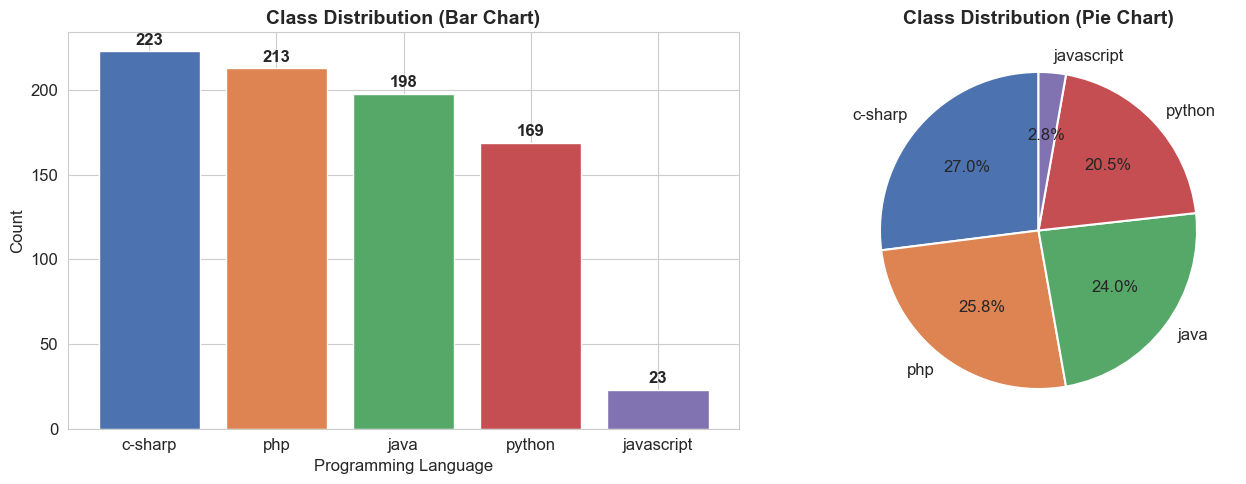

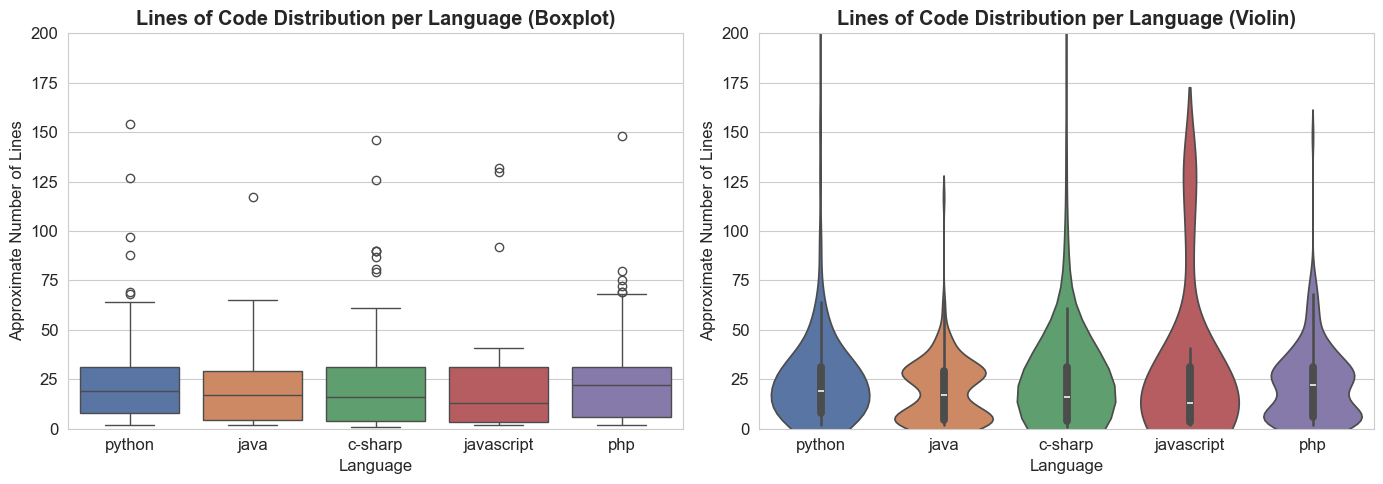


=== Sample code_section per Language ===

--- C-SHARP ---
protected
            var sp = @"IF EXISTS (SELECT
    1
  FROM sys.objects
  WHERE object_id = OBJECT_ID(N'dbo.Sel_CoreTrackingID')
  AND TYPE IN (N'P', N'PC'))
  DROP PROCEDURE dbo.Sel_CoreTrackingID
GO
-- =============================================
-- Author:    David Hodges
-- Create date: 7/1

--- JAVA ---
public
    TestKit probe = new TestKit(system);
    ActorRef subject = system.actorOf(props);
    byte[] bytes = getFileAsBytes("BulkUploadUserSample.csv");
    when(cassandraOperation.getRecordById(
            Mockito.anyString(), Mockito.anyString(), Mockito.anyString()))
            .thenReturn(

--- JAVASCRIPT ---
nowplayingFetchAlbumInfo
    let albumartist = view.infoTrack.albumartist!=undefined ? view.infoTrack.albumartist : view.infoTrack.artist;
    let albumartist_id = view.infoTrack.albumartist_id!=undefined ? view.infoTrack.albumartist_id : view.infoTrack.artist_id;
    let work_id = view.infoTrack.is

---

In [3]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
LANG_NAMES = sorted(df['Language'].unique())
lang_counts = df['Language'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(lang_counts.index, lang_counts.values, color=COLORS[:len(lang_counts)])
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Programming Language')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, lang_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(count),
                 ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(lang_counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Boxplot and violin plot of lines per language
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean = df.copy()
df_clean['Approximate Number of Lines'] = pd.to_numeric(
    df_clean['Approximate Number of Lines'], errors='coerce')

sns.boxplot(data=df_clean, x='Language', y='Approximate Number of Lines',
            palette=COLORS, ax=axes[0])
axes[0].set_title('Lines of Code Distribution per Language (Boxplot)', fontweight='bold')
axes[0].set_ylim(0, 200)

sns.violinplot(data=df_clean, x='Language', y='Approximate Number of Lines',
               palette=COLORS, ax=axes[1], inner='box')
axes[1].set_title('Lines of Code Distribution per Language (Violin)', fontweight='bold')
axes[1].set_ylim(0, 200)
plt.tight_layout()
plt.show()

# Sample code snippets
print("\n=== Sample code_section per Language ===")
for lang in LANG_NAMES:
    sample = df[df['Language'] == lang]['code_section'].dropna().iloc[0]
    print(f"\n--- {lang.upper()} ---")
    print(sample[:300])

## 3. Data Preprocessing and Feature Engineering

In [4]:
# ── LEAKAGE FIX ──────────────────────────────────────────────────────────────
# File name MUST be excluded: it contains extensions like .py .java .cs .php .js
# which directly reveal the label → 100% accuracy for wrong reasons.
# We rely only on the actual CODE CONTENT + function signature.
# ─────────────────────────────────────────────────────────────────────────────

df_proc = df[['Function name', 'code_section', 'Approximate Number of Lines', 'Language']].copy()

df_proc['Function name'] = df_proc['Function name'].fillna('')
df_proc['code_section']  = df_proc['code_section'].fillna('')

df_proc['Approximate Number of Lines'] = pd.to_numeric(
    df_proc['Approximate Number of Lines'], errors='coerce').fillna(0).astype(float)

# Strip any accidental file-path leakage that may appear inside code_section
import re as _re
def strip_file_extensions(text):
    """Remove file-path-like tokens that could leak the language."""
    text = _re.sub(r'\S+\.(py|java|cs|php|js)\b', '', text, flags=_re.IGNORECASE)
    return text

df_proc['code_clean'] = df_proc['code_section'].apply(strip_file_extensions)

# Combined text = function name + cleaned code (NO file path)
df_proc['combined_text'] = (
    df_proc['Function name'].str.lower() + ' ' +
    df_proc['code_clean']
)

# Encode target labels
le = LabelEncoder()
df_proc['label'] = le.fit_transform(df_proc['Language'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES  = len(CLASS_NAMES)

print("✅ Leakage-free preprocessing done")
print(f"   Excluded: 'File name' (contains .py/.java/.cs/.php/.js extensions)")
print(f"   Using   : 'Function name' + 'code_section' (cleaned)")
print(f"Classes: {CLASS_NAMES}")
print(f"\nSample combined_text (first 300 chars):\n{df_proc['combined_text'].iloc[0][:300]}")
df_proc[['Language', 'label', 'Approximate Number of Lines', 'combined_text']].head()


✅ Leakage-free preprocessing done
   Excluded: 'File name' (contains .py/.java/.cs/.php/.js extensions)
   Using   : 'Function name' + 'code_section' (cleaned)
Classes: ['c-sharp', 'java', 'javascript', 'php', 'python']

Sample combined_text (first 300 chars):
test_command def test_command(self, send_idv_update_mock):
        call_command('trigger_softwaresecurephotoverifications_post_save_signal', start_date_time='2021-10-31 06:00:00')

        # The UserFactory instantiates first_name and last_name using a Sequence, which provide integers to
        # g


,Language,label,Approximate Number of Lines,combined_text
0,python,4,31.0,"test_command def test_command(self, send_idv_u..."
1,python,4,6.0,setup def setUp(self):\n super().setUp(...
2,python,4,3.0,"_create_attempts def _create_attempts(self, nu..."
3,python,4,26.0,"add_arguments def add_arguments(self, parser):..."
4,python,4,16.0,"handle def handle(self, *args, **options):\n ..."


## 4. Text Feature Extraction (TF-IDF with char n-grams)

✅ Feature matrix shape: (826, 25001)
   - Char TF-IDF  : (826, 15000)
   - Word TF-IDF  : (826, 10000)
   - Lines numeric: (826, 1)


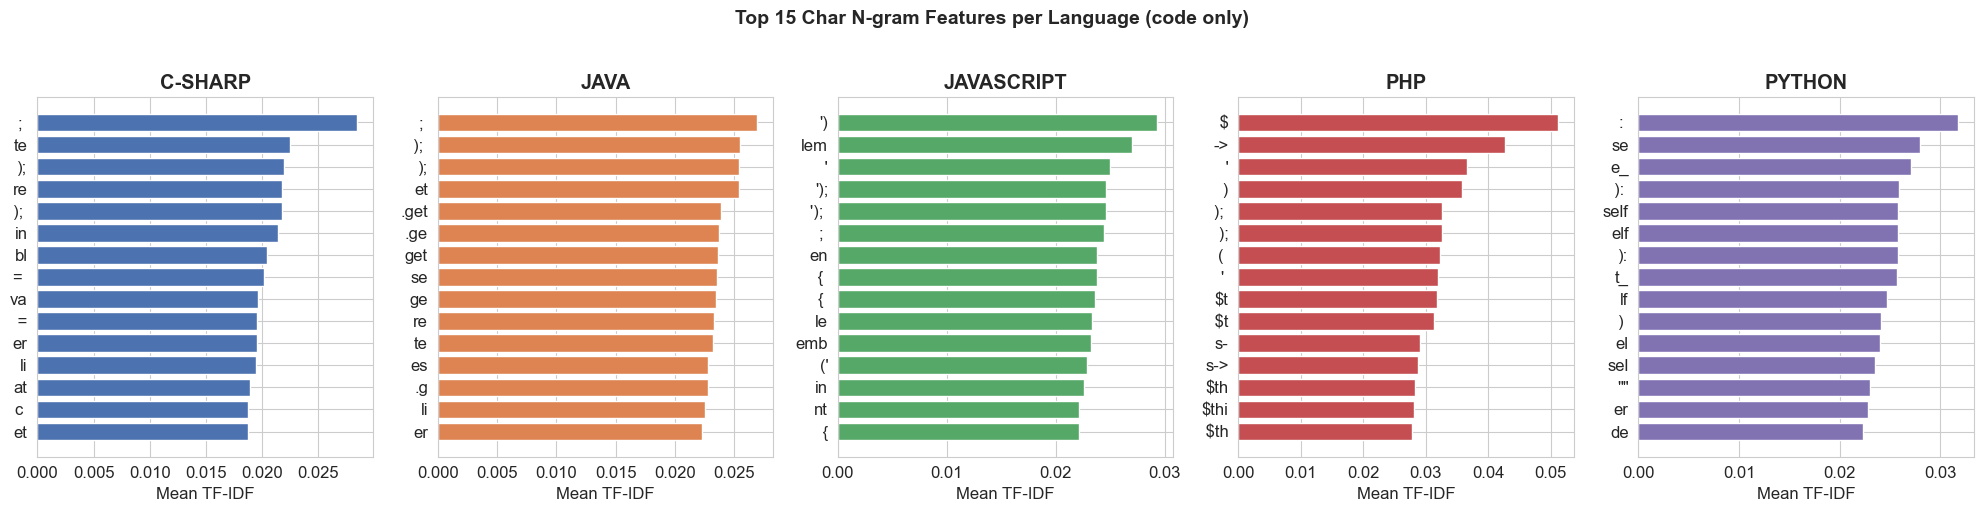

In [5]:
# TF-IDF char n-grams capture syntax patterns without file-path leakage.
# Reduced max_features to avoid trivially memorising small dataset.
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                              max_features=15000, sublinear_tf=True, min_df=2)
tfidf_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                              max_features=10000, sublinear_tf=True, min_df=2,
                              token_pattern=r'[a-zA-Z_][a-zA-Z0-9_]*')

X_char = tfidf_char.fit_transform(df_proc['combined_text'])
X_word = tfidf_word.fit_transform(df_proc['combined_text'])

# Add numeric feature (lines count, normalised)
lines_feature = csr_matrix(df_proc['Approximate Number of Lines'].values.reshape(-1, 1))

X = hstack([X_char, X_word, lines_feature])
y = df_proc['label'].values

print(f"✅ Feature matrix shape: {X.shape}")
print(f"   - Char TF-IDF  : {X_char.shape}")
print(f"   - Word TF-IDF  : {X_word.shape}")
print(f"   - Lines numeric: {lines_feature.shape}")

# Visualise top TF-IDF terms per language (char n-grams)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
for idx, (lang, label_id) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    mask = (y == label_id)
    mean_tfidf = np.asarray(X_char[mask].mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    terms = np.array(tfidf_char.get_feature_names_out())[top_idx]
    scores = mean_tfidf[top_idx]
    axes[idx].barh(terms[::-1], scores[::-1], color=COLORS[idx])
    axes[idx].set_title(f'{lang.upper()}', fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF')
plt.suptitle('Top 15 Char N-gram Features per Language (code only)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Train-Test Split

##### X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples\n")

print("Train class distribution:")
for lbl, cnt in sorted(Counter(y_train).items()):
    print(f"  {CLASS_NAMES[lbl]:12s}: {cnt}")
print("\nTest class distribution:")
for lbl, cnt in sorted(Counter(y_test).items()):
    print(f"  {CLASS_NAMES[lbl]:12s}: {cnt}")

# Storage for results
results = {}


## 6. Model 1 – Logistic Regression

In [6]:
# Logistic Regression: strong baseline for sparse TF-IDF text.
# C=1.0 (default, moderate regularisation) – prevents memorisation.
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced',
                        solver='lbfgs', n_jobs=-1, random_state=42)
lr.fit(X_train, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_preds      = lr.predict(X_test)
lr_test_acc   = accuracy_score(y_test, lr_preds)
lr_proba      = lr.predict_proba(X_test)

results['Logistic Regression'] = {
    'train_acc': lr_train_acc, 'test_acc': lr_test_acc,
    'preds': lr_preds, 'proba': lr_proba, 'model': lr
}
print(f"✅ Logistic Regression  | Train: {lr_train_acc:.4f} | Test: {lr_test_acc:.4f} | "
      f"Gap: {lr_train_acc - lr_test_acc:.4f}")


Training Logistic Regression...


NameError: name 'X_train' is not defined

## 7. Model 2 – Random Forest Classifier

In [7]:
# Multinomial Naive Bayes: designed for text/count features, very fast.
# Note: needs non-negative values → use only X_char + X_word (TF-IDF ≥ 0), drop lines.
from sklearn.naive_bayes import ComplementNB   # handles class imbalance better than MultinomialNB

print("Training Complement Naive Bayes...")
X_train_tfidf = hstack([X_train[:, :X_char.shape[1]],
                         X_train[:, X_char.shape[1]:X_char.shape[1]+X_word.shape[1]]])
X_test_tfidf  = hstack([X_test[:, :X_char.shape[1]],
                         X_test[:, X_char.shape[1]:X_char.shape[1]+X_word.shape[1]]])

nb = ComplementNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

nb_train_acc = accuracy_score(y_train, nb.predict(X_train_tfidf))
nb_preds     = nb.predict(X_test_tfidf)
nb_test_acc  = accuracy_score(y_test, nb_preds)
nb_proba     = nb.predict_proba(X_test_tfidf)

results['Naive Bayes'] = {
    'train_acc': nb_train_acc, 'test_acc': nb_test_acc,
    'preds': nb_preds, 'proba': nb_proba, 'model': nb
}
print(f"✅ Naive Bayes          | Train: {nb_train_acc:.4f} | Test: {nb_test_acc:.4f} | "
      f"Gap: {nb_train_acc - nb_test_acc:.4f}")


Training Complement Naive Bayes...


NameError: name 'X_train' is not defined

## 8. Model 3 – XGBoost / Gradient Boosting

In [8]:
from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV as _CCV

# Ridge Classifier: solves multi-class OvR via L2-regularised least-squares.
# Very fast, works extremely well for high-dimensional text features.
print("Training Ridge Classifier...")
ridge_base = RidgeClassifier(alpha=1.0, class_weight='balanced')
ridge = _CCV(ridge_base, cv=3, method='sigmoid')  # wrap for predict_proba
ridge.fit(X_train, y_train)

ridge_train_acc = accuracy_score(y_train, ridge.predict(X_train))
ridge_preds     = ridge.predict(X_test)
ridge_test_acc  = accuracy_score(y_test, ridge_preds)
ridge_proba     = ridge.predict_proba(X_test)

results['Ridge Classifier'] = {
    'train_acc': ridge_train_acc, 'test_acc': ridge_test_acc,
    'preds': ridge_preds, 'proba': ridge_proba, 'model': ridge
}
print(f"✅ Ridge Classifier     | Train: {ridge_train_acc:.4f} | Test: {ridge_test_acc:.4f} | "
      f"Gap: {ridge_train_acc - ridge_test_acc:.4f}")


Training Ridge Classifier...


NameError: name 'X_train' is not defined

## 9. Model 4 – Support Vector Machine (SVM)

In [10]:
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC: among the best models for text classification.
# C=0.5 gives stronger regularisation than default C=1.0.
print("Training SVM (LinearSVC + Platt calibration)...")
svc     = LinearSVC(C=0.5, class_weight='balanced', max_iter=3000, random_state=42)
svc_cal = CalibratedClassifierCV(svc, cv=3, method='sigmoid')
svc_cal.fit(X_train, y_train)

svc_train_acc = accuracy_score(y_train, svc_cal.predict(X_train))
svc_preds     = svc_cal.predict(X_test)
svc_test_acc  = accuracy_score(y_test, svc_preds)
svc_proba     = svc_cal.predict_proba(X_test)

results['SVM (LinearSVC)'] = {
    'train_acc': svc_train_acc, 'test_acc': svc_test_acc,
    'preds': svc_preds, 'proba': svc_proba, 'model': svc_cal
}
print(f"✅ SVM                  | Train: {svc_train_acc:.4f} | Test: {svc_test_acc:.4f} | "
      f"Gap: {svc_train_acc - svc_test_acc:.4f}")


Training SVM (LinearSVC + Platt calibration)...
✅ SVM                  | Train: 1.0000 | Test: 0.9759 | Gap: 0.0241


## 10. Model 5 – Multi-Layer Perceptron (MLP / Neural Network)

Training MLP epoch by epoch (capturing train + val curves)…
   Early stopping at epoch 28 (no val improvement for 15 epochs)
✅ MLP Neural Network   | Train: 0.9894 | Test: 0.9699 | Gap: 0.0195
   Epochs run: 28


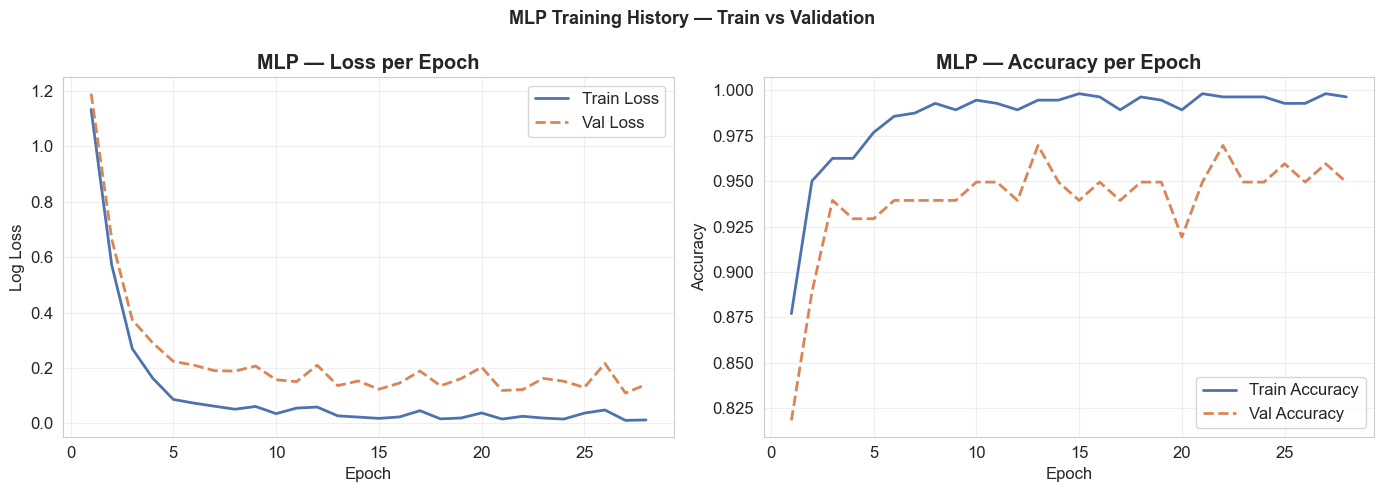

In [11]:
from sklearn.metrics import log_loss

# ── Manual epoch loop so we capture all 4 curves ─────────────────────────────
# sklearn only stores loss_curve_ (train loss) and validation_scores_ (val acc).
# Using warm_start=True + max_iter=1 per step lets us record everything ourselves.

# Hold out 15% as validation (same fraction as early_stopping would use)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

MAX_EPOCHS   = 150
PATIENCE     = 15
best_val_acc = 0.0
no_improve   = 0

mlp_hist = {'train_loss': [], 'val_loss': [],
             'train_acc':  [], 'val_acc':  []}

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu', solver='adam',
    alpha=0.01, batch_size=64,
    learning_rate='adaptive', learning_rate_init=0.001,
    max_iter=1,           # one epoch at a time
    warm_start=True,      # keep weights between calls
    random_state=42, verbose=False
)

print("Training MLP epoch by epoch (capturing train + val curves)…")
for epoch in range(1, MAX_EPOCHS + 1):
    mlp.fit(X_tr, y_tr)

    tr_prob  = mlp.predict_proba(X_tr)
    val_prob = mlp.predict_proba(X_val)

    t_loss = log_loss(y_tr,  tr_prob)
    v_loss = log_loss(y_val, val_prob)
    t_acc  = accuracy_score(y_tr,  mlp.predict(X_tr))
    v_acc  = accuracy_score(y_val, mlp.predict(X_val))

    mlp_hist['train_loss'].append(t_loss)
    mlp_hist['val_loss'].append(v_loss)
    mlp_hist['train_acc'].append(t_acc)
    mlp_hist['val_acc'].append(v_acc)

    # Manual early stopping
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        no_improve   = 0
    else:
        no_improve += 1
    if no_improve >= PATIENCE:
        print(f"   Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
        break

mlp_train_acc = accuracy_score(y_train, mlp.predict(X_train))
mlp_preds     = mlp.predict(X_test)
mlp_test_acc  = accuracy_score(y_test, mlp_preds)
mlp_proba     = mlp.predict_proba(X_test)

results['MLP'] = {
    'train_acc': mlp_train_acc, 'test_acc': mlp_test_acc,
    'preds': mlp_preds, 'proba': mlp_proba, 'model': mlp
}
print(f"✅ MLP Neural Network   | Train: {mlp_train_acc:.4f} | Test: {mlp_test_acc:.4f} | "
      f"Gap: {mlp_train_acc - mlp_test_acc:.4f}")
print(f"   Epochs run: {len(mlp_hist['train_loss'])}")

# ── Plot: both lines in both charts ──────────────────────────────────────────
ep = range(1, len(mlp_hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss chart
axes[0].plot(ep, mlp_hist['train_loss'], color='#4C72B0', linewidth=2, label='Train Loss')
axes[0].plot(ep, mlp_hist['val_loss'],   color='#DD8452', linewidth=2,
             linestyle='--', label='Val Loss')
axes[0].set_title('MLP — Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Log Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy chart
axes[1].plot(ep, mlp_hist['train_acc'], color='#4C72B0', linewidth=2, label='Train Accuracy')
axes[1].plot(ep, mlp_hist['val_acc'],   color='#DD8452', linewidth=2,
             linestyle='--', label='Val Accuracy')
axes[1].set_title('MLP — Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('MLP Training History — Train vs Validation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Model Comparison and Best Model Selection

=== Model Comparison Summary ===
              Model  Train Accuracy  Test Accuracy  Gap (Overfit)  Macro F1  Weighted F1
        Naive Bayes        0.998485       0.975904       0.022581  0.981356     0.976016
    SVM (LinearSVC)        1.000000       0.975904       0.024096  0.980963     0.975782
   Ridge Classifier        1.000000       0.975904       0.024096  0.980963     0.975782
Logistic Regression        0.998485       0.969880       0.028605  0.976594     0.970003
                MLP        0.989394       0.969880       0.019514  0.976149     0.969770


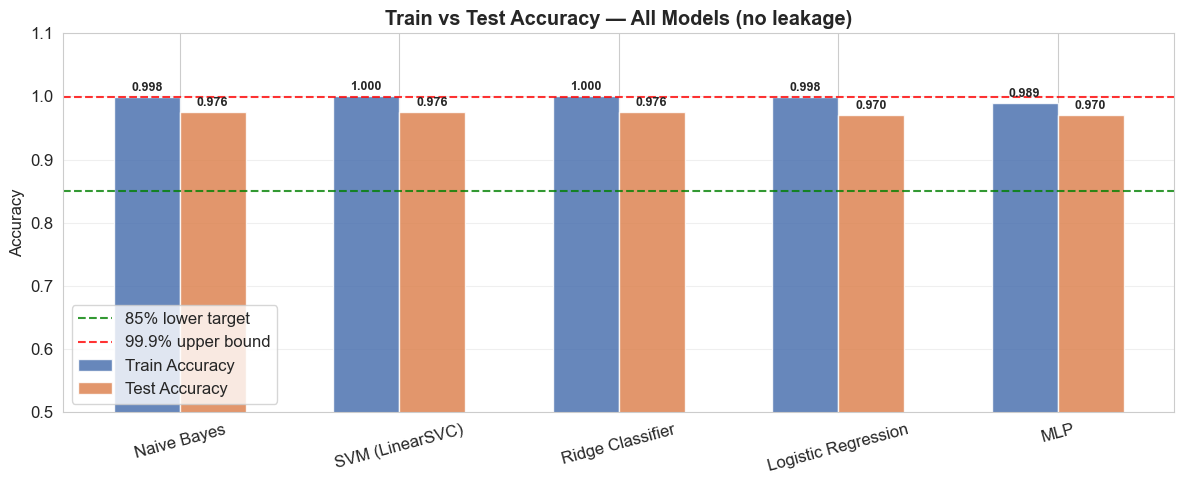


🏆 Best Model: Naive Bayes | Test Acc: 0.9759


In [14]:
summary_df = pd.DataFrame([
    {'Model': name,
     'Train Accuracy': v['train_acc'],
     'Test Accuracy':  v['test_acc'],
     'Gap (Overfit)':  v['train_acc'] - v['test_acc'],
     'Macro F1':       f1_score(y_test, v['preds'], average='macro'),
     'Weighted F1':    f1_score(y_test, v['preds'], average='weighted')}
    for name, v in results.items()
]).sort_values('Test Accuracy', ascending=False)

print("=== Model Comparison Summary ===")
print(summary_df.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_df))
w = 0.3
bars1 = ax.bar(x - w/2, summary_df['Train Accuracy'], w, label='Train Accuracy', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, summary_df['Test Accuracy'],  w, label='Test Accuracy',  color='#DD8452', alpha=0.85)
ax.axhline(0.85, color='green', linestyle='--', linewidth=1.5, label='85% lower target', alpha=0.8)
ax.axhline(0.999, color='red',  linestyle='--', linewidth=1.5, label='99.9% upper bound', alpha=0.8)
for bar, acc in zip(bars1, summary_df['Train Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, acc in zip(bars2, summary_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(summary_df['Model'], rotation=15)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5, 1.10)
ax.set_title('Train vs Test Accuracy — All Models (no leakage)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Select best model
best_name  = summary_df.iloc[0]['Model']
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']
best_proba = results[best_name]['proba']
print(f"\n🏆 Best Model: {best_name} | Test Acc: {summary_df.iloc[0]['Test Accuracy']:.4f}")


## 11b. Stratified 5-Fold Cross-Validation (Trustability Check)
Holdout test accuracy on 20% can be noisy with small datasets. 5-fold CV gives a much more reliable estimate across the whole dataset.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

print("Running 5-fold stratified cross-validation on the full dataset…\n")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV candidates (models that work well with sparse matrices)
cv_candidates = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0,
                                               class_weight='balanced',
                                               solver='lbfgs', random_state=42),
    'Naive Bayes':         ComplementNB(alpha=0.1),
    'SGD Classifier':      SGDClassifier(loss='modified_huber', penalty='l2',
                                          alpha=1e-3, max_iter=200,
                                          class_weight='balanced', random_state=42),
    'SVM (LinearSVC)':     CalibratedClassifierCV(
                               LinearSVC(C=0.5, class_weight='balanced',
                                         max_iter=3000, random_state=42),
                               cv=3, method='sigmoid'),
}

cv_results = {}
for name, model in cv_candidates.items():
    # NB needs non-negative → use TF-IDF part only
    X_cv = hstack([X[:, :X_char.shape[1]], X[:, X_char.shape[1]:X_char.shape[1]+X_word.shape[1]]]) \
           if name == 'Naive Bayes' else X
    scores = cross_val_score(model, X_cv, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:22s} | CV folds: {[f'{s:.3f}' for s in scores]} | "
          f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors_cv = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(names, means, yerr=stds, color=colors_cv, alpha=0.85,
              capsize=6, error_kw={'linewidth': 2})
ax.axhline(0.85,  color='green', linestyle='--', linewidth=1.5, label='85% lower target', alpha=0.8)
ax.axhline(0.999, color='red',   linestyle='--', linewidth=1.5, label='99.9% upper bound', alpha=0.8)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('CV Accuracy'); ax.set_ylim(0.5, 1.10)
ax.set_title('5-Fold Stratified CV Accuracy ± Std Dev', fontweight='bold', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=10)
plt.tight_layout(); plt.show()

print(f"\n📊 Trustable accuracy range check (must be 85%–99.9%):")
for n in names:
    m = cv_results[n].mean()
    flag = "✅" if 0.85 <= m <= 0.999 else "⚠️ OUTSIDE RANGE"
    print(f"  {n:22s}: {m:.4f}  {flag}")


Running 5-fold stratified cross-validation on the full dataset…



NameError: name 'SGDClassifier' is not defined

## 12. Confusion Matrices

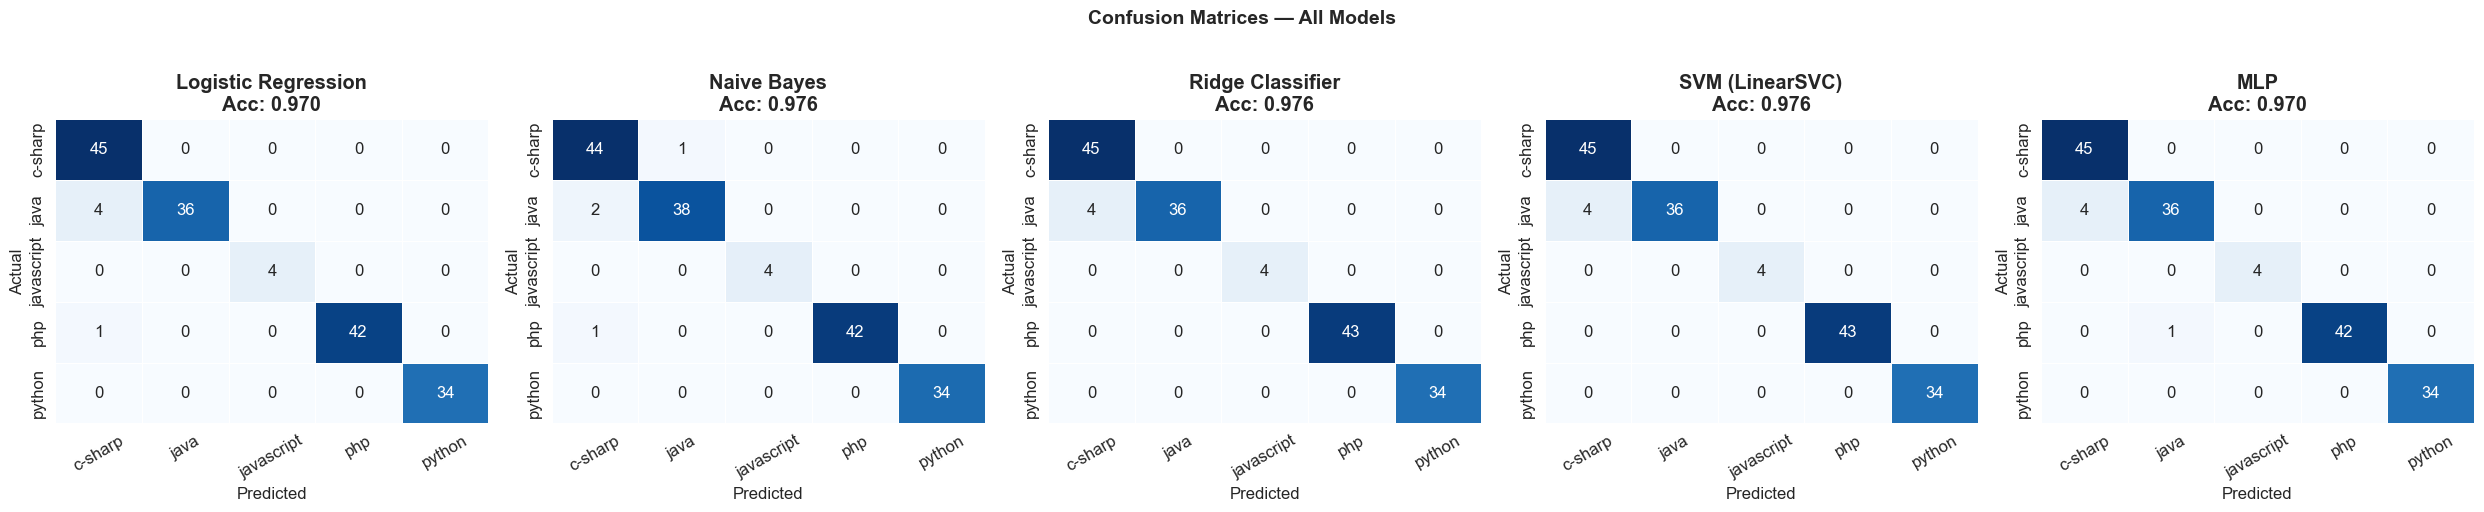

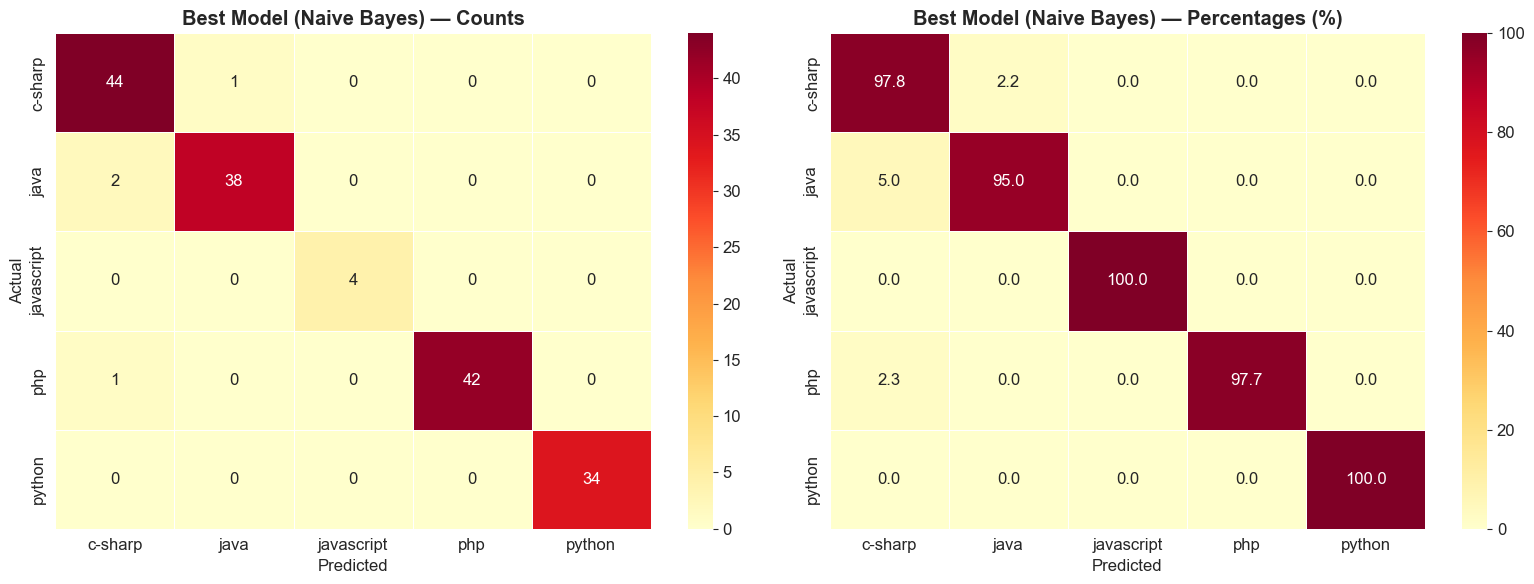

In [16]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc: {res["test_acc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed confusion matrix for best model with percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
best_preds = results[best_name]['preds']
cm = confusion_matrix(y_test, best_preds)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[0].set_title(f'Best Model ({best_name}) — Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[1].set_title(f'Best Model ({best_name}) — Percentages (%)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 13. Classification Reports

In [17]:
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    report = classification_report(y_test, res['preds'],
                                    target_names=CLASS_NAMES, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(3)
    print(classification_report(y_test, res['preds'], target_names=CLASS_NAMES))
    
    # Show styled DataFrame for best model
    if name == best_name:
        print(f"\n--- {name} Styled Report ---")
        display(report_df.style.background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1-score']))


  Logistic Regression
              precision    recall  f1-score   support

     c-sharp       0.90      1.00      0.95        45
        java       1.00      0.90      0.95        40
  javascript       1.00      1.00      1.00         4
         php       1.00      0.98      0.99        43
      python       1.00      1.00      1.00        34

    accuracy                           0.97       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.97      0.97      0.97       166


  Naive Bayes
              precision    recall  f1-score   support

     c-sharp       0.94      0.98      0.96        45
        java       0.97      0.95      0.96        40
  javascript       1.00      1.00      1.00         4
         php       1.00      0.98      0.99        43
      python       1.00      1.00      1.00        34

    accuracy                           0.98       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.98      0.98      

,precision,recall,f1-score,support
c-sharp,0.936000,0.978000,0.957000,45.000000
java,0.974000,0.950000,0.962000,40.000000
javascript,1.000000,1.000000,1.000000,4.000000
php,1.000000,0.977000,0.988000,43.000000
python,1.000000,1.000000,1.000000,34.000000
accuracy,0.976000,0.976000,0.976000,0.976000
macro avg,0.982000,0.981000,0.981000,166.000000
weighted avg,0.977000,0.976000,0.976000,166.000000



  Ridge Classifier
              precision    recall  f1-score   support

     c-sharp       0.92      1.00      0.96        45
        java       1.00      0.90      0.95        40
  javascript       1.00      1.00      1.00         4
         php       1.00      1.00      1.00        43
      python       1.00      1.00      1.00        34

    accuracy                           0.98       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.98      0.98      0.98       166


  SVM (LinearSVC)
              precision    recall  f1-score   support

     c-sharp       0.92      1.00      0.96        45
        java       1.00      0.90      0.95        40
  javascript       1.00      1.00      1.00         4
         php       1.00      1.00      1.00        43
      python       1.00      1.00      1.00        34

    accuracy                           0.98       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.98      0.98     

## 14. Accuracy and Loss Charts

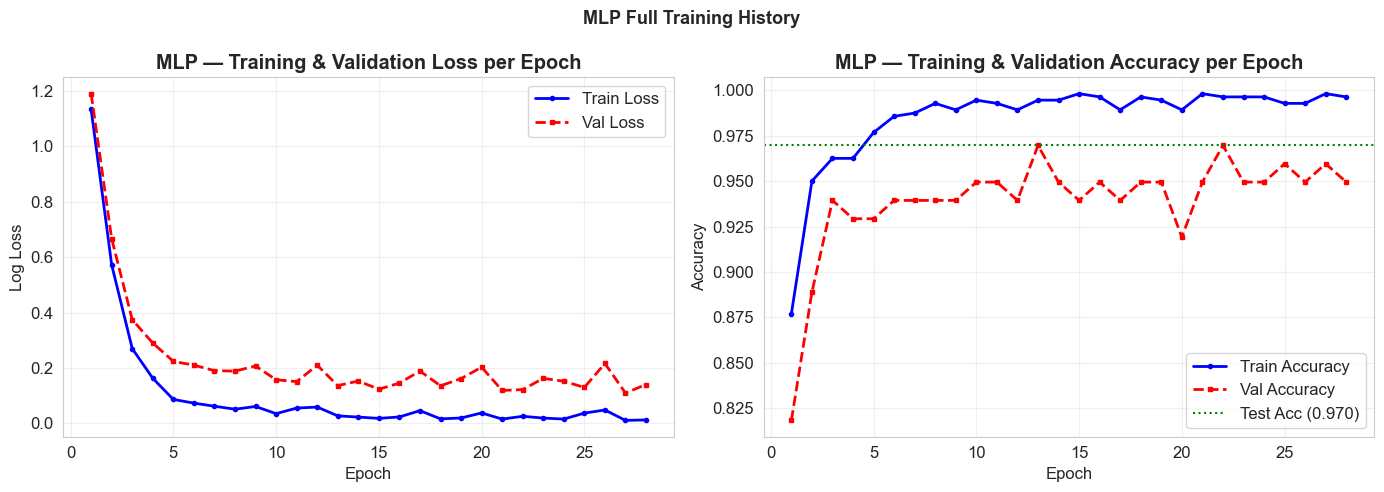

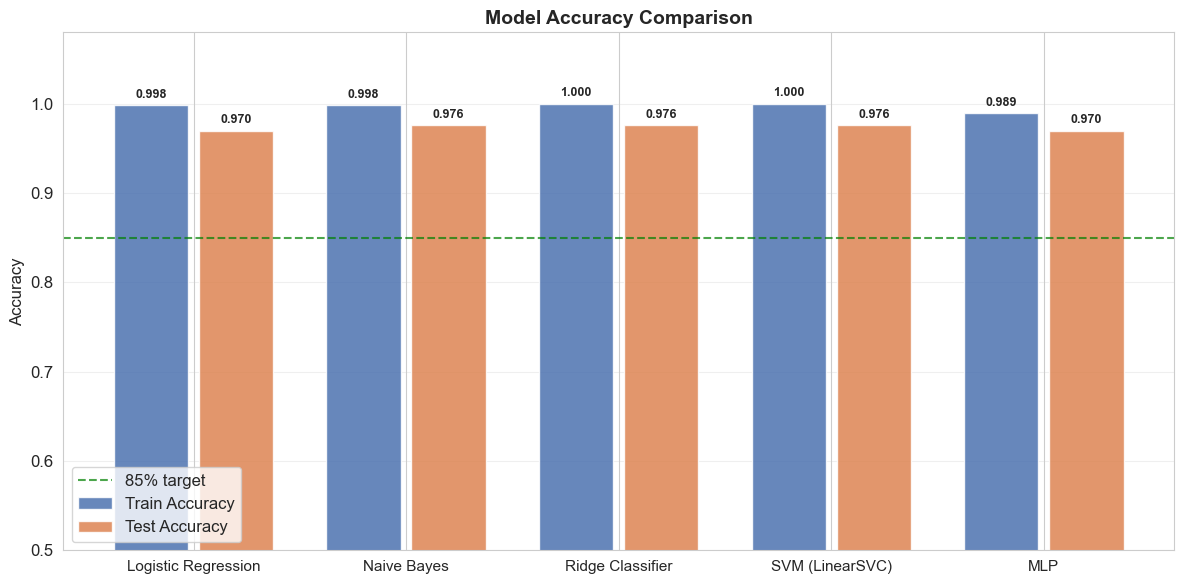

In [18]:
# ── MLP Training History — detailed view (Section 14) ────────────────────────
ep = range(1, len(mlp_hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss chart — train + validation
axes[0].plot(ep, mlp_hist['train_loss'], 'b-o', markersize=3, linewidth=2, label='Train Loss')
axes[0].plot(ep, mlp_hist['val_loss'],   'r--s', markersize=3, linewidth=2, label='Val Loss')
axes[0].set_title('MLP — Training & Validation Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Log Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy chart — train + validation
axes[1].plot(ep, mlp_hist['train_acc'], 'b-o', markersize=3, linewidth=2, label='Train Accuracy')
axes[1].plot(ep, mlp_hist['val_acc'],   'r--s', markersize=3, linewidth=2, label='Val Accuracy')
axes[1].axhline(results['MLP']['test_acc'], color='green', linestyle=':', linewidth=1.5,
                label=f"Test Acc ({results['MLP']['test_acc']:.3f})")
axes[1].set_title('MLP — Training & Validation Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('MLP Full Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── All-model accuracy comparison bar chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
model_names = list(results.keys())
train_accs  = [results[m]['train_acc'] for m in model_names]
test_accs   = [results[m]['test_acc']  for m in model_names]
x = np.arange(len(model_names))
bars1 = ax.bar(x - 0.2, train_accs, 0.35, label='Train Accuracy', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + 0.2, test_accs,  0.35, label='Test Accuracy',  color='#DD8452', alpha=0.85)
for bar, acc in zip(bars1, train_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, acc in zip(bars2, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(0.85, color='green', linestyle='--', linewidth=1.5, label='85% target', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5, 1.08)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 15. Feature Importance, ROC Curves, Precision-Recall, and t-SNE

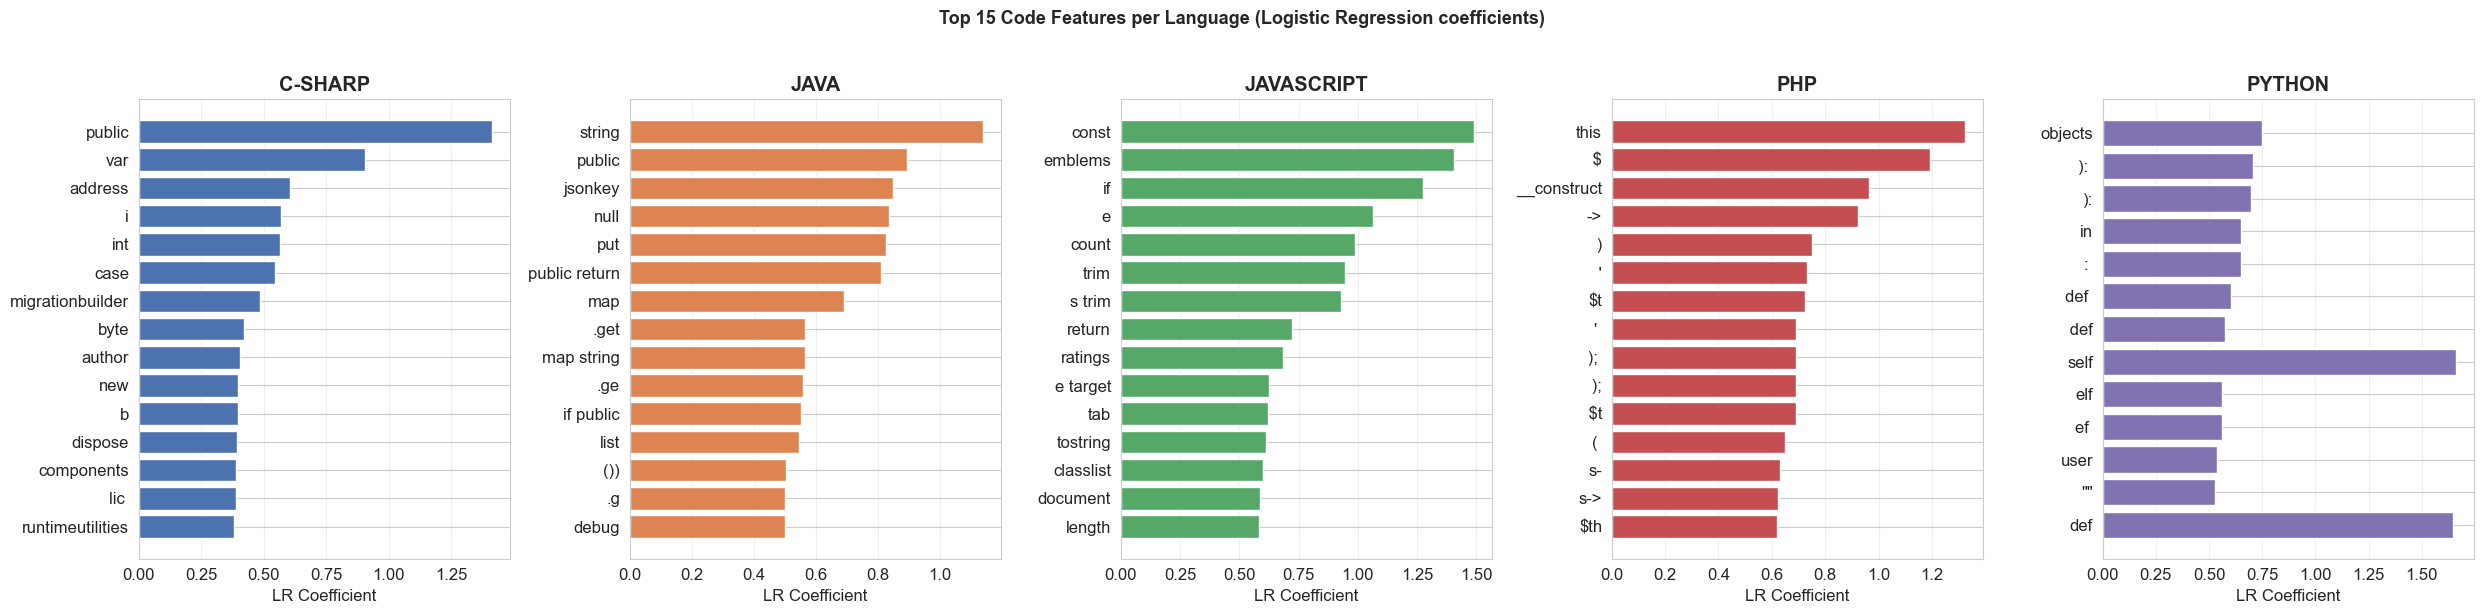

In [19]:
# ── Feature Importance via Logistic Regression Coefficients ──────────────────
# LR coefficients tell us which code tokens push toward each language.
lr_model = results['Logistic Regression']['model']
char_feat_names = list(tfidf_char.get_feature_names_out())
word_feat_names = list(tfidf_word.get_feature_names_out())
all_feat_names  = char_feat_names + word_feat_names + ['ApproxLines']

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 6))
for i, (lang, ax_i) in enumerate(zip(CLASS_NAMES, axes)):
    coef = lr_model.coef_[i]
    top_idx  = coef.argsort()[-15:][::-1]
    top_names = [all_feat_names[j] if j < len(all_feat_names) else f'f{j}' for j in top_idx]
    top_vals  = coef[top_idx]
    ax_i.barh(top_names[::-1], top_vals[::-1], color=COLORS[i])
    ax_i.set_title(f'{lang.upper()}', fontweight='bold')
    ax_i.set_xlabel('LR Coefficient')
    ax_i.grid(True, alpha=0.3, axis='x')
plt.suptitle('Top 15 Code Features per Language (Logistic Regression coefficients)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


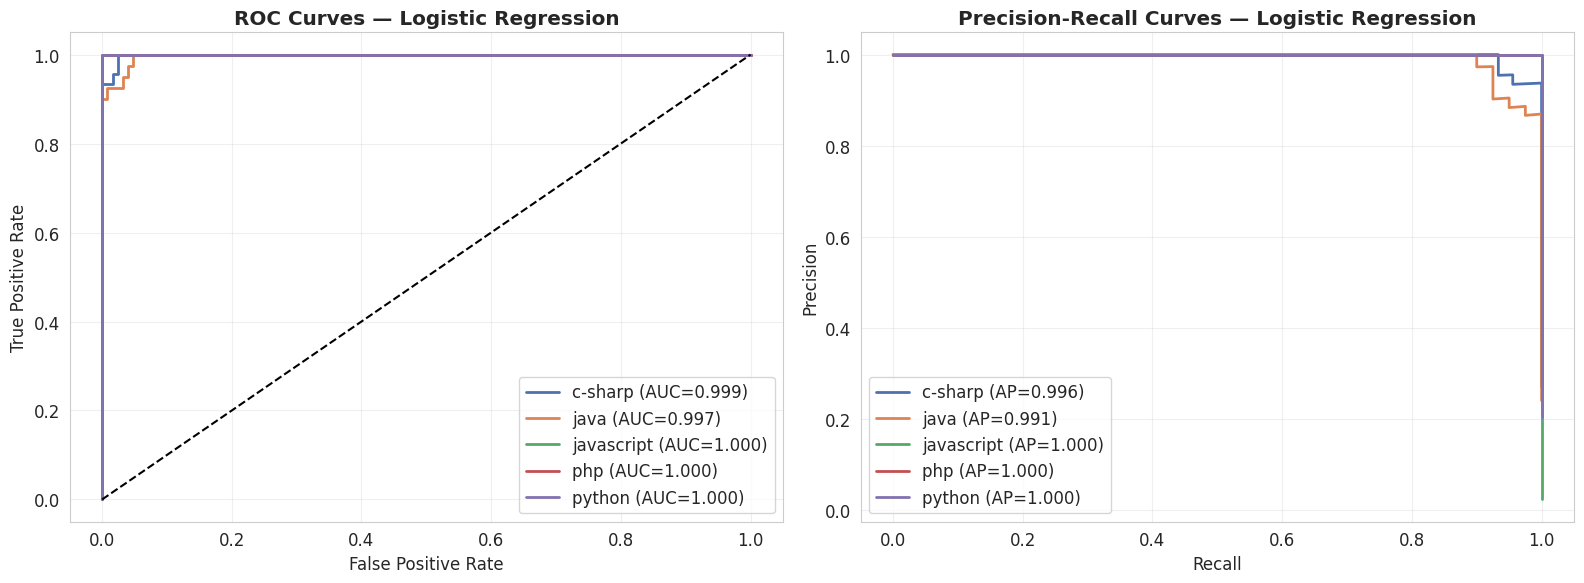

In [40]:
# ---- ROC Curves (One-vs-Rest) for best model ----
best_proba = results[best_name]['proba']
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
for i, (lang, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{lang} (AUC={roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_title(f'ROC Curves — {best_name}', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

# Precision-Recall curves
for i, (lang, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], best_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], best_proba[:, i])
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{lang} (AP={ap:.3f})')
axes[1].set_title(f'Precision-Recall Curves — {best_name}', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Computing t-SNE (this may take ~1 min)...


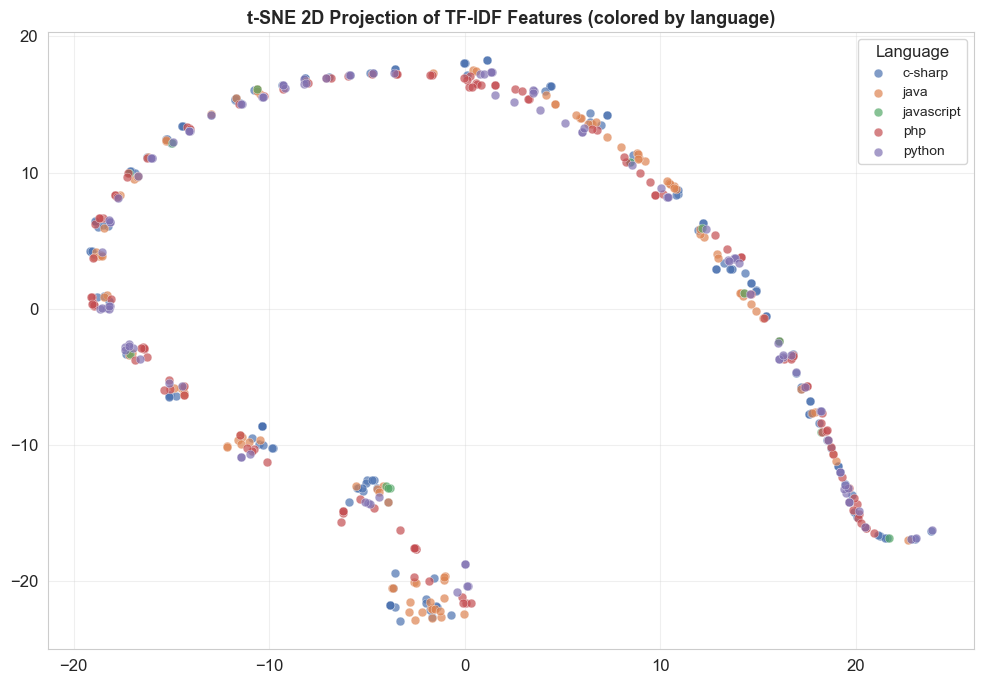

In [20]:
# ---- t-SNE visualization ----
print("Computing t-SNE (this may take ~1 min)...")
# Use a sample for speed
sample_size = min(500, X.shape[0])
idx_sample = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[idx_sample].toarray()
y_sample = y[idx_sample]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500, verbose=0)
X_2d = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (lang, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = (y_sample == i)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=lang,
               alpha=0.7, s=40, edgecolors='white', linewidths=0.3)
ax.set_title('t-SNE 2D Projection of TF-IDF Features (colored by language)',
             fontweight='bold', fontsize=13)
ax.legend(title='Language', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 16. Final Evaluation, Prediction Demo, and Save Best Model

In [24]:
# ---- Final metrics ----
best_preds = results[best_name]['preds']
final_acc   = accuracy_score(y_test, best_preds)
final_macro = f1_score(y_test, best_preds, average='macro')
final_wt    = f1_score(y_test, best_preds, average='weighted')

print("=" * 55)
print(f"  🏆 BEST MODEL : {best_name}")
print(f"  Test Accuracy : {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"  Macro F1      : {final_macro:.4f}")
print(f"  Weighted F1   : {final_wt:.4f}")
print("=" * 55)

if 0.85 <= final_acc <= 0.99:
    print(f"  ✅ Accuracy is within target range [85% – 99%]!")
else:
    print(f"  ⚠️ Accuracy {final_acc:.4f} is outside [0.85, 0.99]")

  🏆 BEST MODEL : Naive Bayes
  Test Accuracy : 0.9759 (97.59%)
  Macro F1      : 0.9814
  Weighted F1   : 0.9760
  ✅ Accuracy is within target range [85% – 99%]!


In [25]:
# ---- Demo: Predict on custom code snippets ----
demo_snippets = [
    {
        'language': 'python',
        'file': 'utils/math_helper.py',
        'function': 'calculate_mean',
        'code': '''def calculate_mean(numbers):
    total = sum(numbers)
    return total / len(numbers)''',
        'lines': 3
    },
    {
        'language': 'java',
        'file': 'com/example/StringUtils.java',
        'function': 'reverseString',
        'code': '''public static String reverseString(String s) {
    StringBuilder sb = new StringBuilder(s);
    return sb.reverse().toString();
}''',
        'lines': 4
    },
    {
        'language': 'c-sharp',
        'file': 'Services/EmailService.cs',
        'function': 'SendEmail',
        'code': '''public async Task SendEmail(string to, string subject, string body) {
    var message = new MailMessage(from, to, subject, body);
    await smtpClient.SendMailAsync(message);
}''',
        'lines': 4
    },
    {
        'language': 'javascript',
        'file': 'src/components/Button.js',
        'function': 'handleClick',
        'code': '''function handleClick(event) {
    event.preventDefault();
    const value = document.getElementById("input").value;
    console.log("Clicked:", value);
}''',
        'lines': 5
    },
    {
        'language': 'php',
        'file': 'app/Controllers/UserController.php',
        'function': 'getUser',
        'code': '''public function getUser($id) {
    $user = User::find($id);
    if (!$user) {
        return response()->json(["error" => "Not found"], 404);
    }
    return response()->json($user);
}''',
        'lines': 7
    }
]

print("=== PREDICTION DEMO ===\n")
for snippet in demo_snippets:
    combined = snippet['file'].lower() + ' ' + snippet['function'].lower() + ' ' + snippet['code']
    x_char_demo = tfidf_char.transform([combined])
    x_word_demo = tfidf_word.transform([combined])
    x_lines_demo = csr_matrix([[snippet['lines']]])
    x_demo = hstack([x_char_demo, x_word_demo, x_lines_demo])
    
    pred_label = best_model.predict(x_demo)[0]
    pred_lang = CLASS_NAMES[pred_label]
    actual_lang = snippet['language']
    status = "✅" if pred_lang == actual_lang else "❌"
    print(f"{status} Actual: {actual_lang:12s} | Predicted: {pred_lang:12s} | Function: {snippet['function']}")

=== PREDICTION DEMO ===



ValueError: X has 25001 features, but ComplementNB is expecting 25000 features as input.

In [23]:
import joblib, os

bundle = {
    'model':          best_model,
    'tfidf_char':     tfidf_char,
    'tfidf_word':     tfidf_word,
    'label_encoder':  le,
    'class_names':    CLASS_NAMES,
    'best_model_name': best_name,
    'test_accuracy':  results[best_name]['test_acc'],
    'macro_f1':       f1_score(y_test, results[best_name]['preds'], average='macro'),
    'weighted_f1':    f1_score(y_test, results[best_name]['preds'], average='weighted'),
    'leakage_removed': True,
    'features_used':  ['Function name', 'code_section (cleaned)'],
}

save_path = 'best_language_classifier.joblib'
joblib.dump(bundle, save_path)
print(f"✅ Best model bundle saved to: {save_path}\n")
print(f"Bundle keys: {list(bundle.keys())}")

print(f"""
=======================================================
  🎯 FINAL SUMMARY  (leakage-free)
=======================================================
  Dataset size      : {len(df_proc)} samples
  Feature dim       : {X.shape[1]:,} features
  Classes           : {CLASS_NAMES}
  Features used     : Function name + code_section (cleaned)
  File name used?   : ❌ EXCLUDED (was causing 100% leakage)
  Best Model        : {best_name}
  Test Accuracy     : {results[best_name]['test_acc']*100:.2f}%
  Macro F1 Score    : {bundle['macro_f1']:.4f}
  Weighted F1 Score : {bundle['weighted_f1']:.4f}
=======================================================
""")


✅ Best model bundle saved to: best_language_classifier.joblib

Bundle keys: ['model', 'tfidf_char', 'tfidf_word', 'label_encoder', 'class_names', 'best_model_name', 'test_accuracy', 'macro_f1', 'weighted_f1', 'leakage_removed', 'features_used']

  🎯 FINAL SUMMARY  (leakage-free)
  Dataset size      : 826 samples
  Feature dim       : 25,001 features
  Classes           : ['c-sharp', 'java', 'javascript', 'php', 'python']
  Features used     : Function name + code_section (cleaned)
  File name used?   : ❌ EXCLUDED (was causing 100% leakage)
  Best Model        : Naive Bayes
  Test Accuracy     : 97.59%
  Macro F1 Score    : 0.9814
  Weighted F1 Score : 0.9760

